In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [40]:
df = pd.read_csv("btcusd_1-min_data.csv")
df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='s')
df.set_index("Timestamp", inplace=True)
df_1h = df.resample('1h').agg({
    'Open': 'first', 
    'High': 'max', 
    'Low': 'min', 
    'Close': 'last', 
    'Volume': 'sum'
})
df_1h.dropna(inplace=True)
print(df_1h)

                         Open      High       Low     Close      Volume
Timestamp                                                              
2012-01-01 10:00:00      4.58      4.58      4.58      4.58    0.000000
2012-01-01 11:00:00      4.58      4.58      4.58      4.58    0.000000
2012-01-01 12:00:00      4.58      4.58      4.58      4.58    0.000000
2012-01-01 13:00:00      4.58      4.58      4.58      4.58    0.000000
2012-01-01 14:00:00      4.58      4.58      4.58      4.58    0.000000
...                       ...       ...       ...       ...         ...
2026-06-07 20:00:00  61308.22  61938.91  61186.21  61852.95   47.327578
2026-06-07 21:00:00  61848.20  61977.99  61623.72  61741.61   40.097036
2026-06-07 22:00:00  61748.22  64196.66  61694.16  62834.39  255.672972
2026-06-07 23:00:00  62831.86  63430.99  62772.72  63315.72  105.506078
2026-06-08 00:00:00  63306.56  63318.99  63117.05  63209.62   31.597776

[126501 rows x 5 columns]


In [41]:
df_1h['Target'] = (df_1h["Close"].shift(-1) > df_1h["Close"]).astype(int)
df_1h.dropna(inplace=True)
display(df_1h[['Close', 'Target']].tail(10))

,Close,Target
Timestamp,,
2026-06-07 15:00:00,62059.22,0
2026-06-07 16:00:00,62051.10,1
2026-06-07 17:00:00,62134.13,0
2026-06-07 18:00:00,62004.33,0
2026-06-07 19:00:00,61299.04,1
2026-06-07 20:00:00,61852.95,0
2026-06-07 21:00:00,61741.61,1
2026-06-07 22:00:00,62834.39,1
2026-06-07 23:00:00,63315.72,0


In [44]:
from sklearn.preprocessing import MinMaxScaler

X = df_1h.drop(columns=['Target'])
y = df_1h['Target']

scaler = MinMaxScaler()
X_scaler = scaler.fit_transform(X)

In [48]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaler, y, test_size=0.2, shuffle=False)
print(X_train.shape)

(101200, 5)


In [52]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input



In [60]:
model = Sequential()
model.add(Input(shape=(5,)))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,497 (9.75 KB)

 Trainable params: 2,497 (9.75 KB)

 Non-trainable params: 0 (0.00 B)

In [61]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [62]:
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/10
3163/3163 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.5196 - loss: 0.6911 - val_accuracy: 0.5051 - val_loss: 0.6931
Epoch 2/10
3163/3163 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.5280 - loss: 0.6876 - val_accuracy: 0.5061 - val_loss: 0.6931
Epoch 3/10
3163/3163 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.5297 - loss: 0.6847 - val_accuracy: 0.5061 - val_loss: 0.6931
Epoch 4/10
3163/3163 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.5278 - loss: 0.6836 - val_accuracy: 0.5061 - val_loss: 0.6935
Epoch 5/10
3163/3163 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - accuracy: 0.5303 - loss: 0.6832 - val_accuracy: 0.4941 - val_loss: 0.6950
Epoch 6/10
3163/3163 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.5307 - loss: 0.6830 - val_accuracy: 0.4984 - val_loss: 0.6933
Epoch 7/10
3163/3163 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.5291 - loss: 0.6829 - val_accuracy: 0.4939 - val_loss: 0.6948
Epoch 8/10
3163/3163 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.5307 - loss: 0

C:\Users\thulana\AppData\Local\Temp\ipykernel_18240\2464429516.py:27: UserWarning: Glyph 3520 (\N{SINHALA LETTER VAYANNA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\thulana\AppData\Local\Temp\ipykernel_18240\2464429516.py:27: UserWarning: Matplotlib currently does not support Sinhala natively.
  plt.tight_layout()
C:\Users\thulana\AppData\Local\Temp\ipykernel_18240\2464429516.py:27: UserWarning: Glyph 3495 (\N{SINHALA LETTER ALPAPRAANA TTAYANNA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\thulana\AppData\Local\Temp\ipykernel_18240\2464429516.py:27: UserWarning: Glyph 3484 (\N{SINHALA LETTER ALPAPRAANA GAYANNA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\thulana\AppData\Local\Temp\ipykernel_18240\2464429516.py:27: UserWarning: Glyph 3499 (\N{SINHALA LETTER MUURDHAJA NAYANNA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\thulana\AppData\Local\Temp\ipykernel_18240\2464429516.py:27: UserWarning: Glyph 3505 (

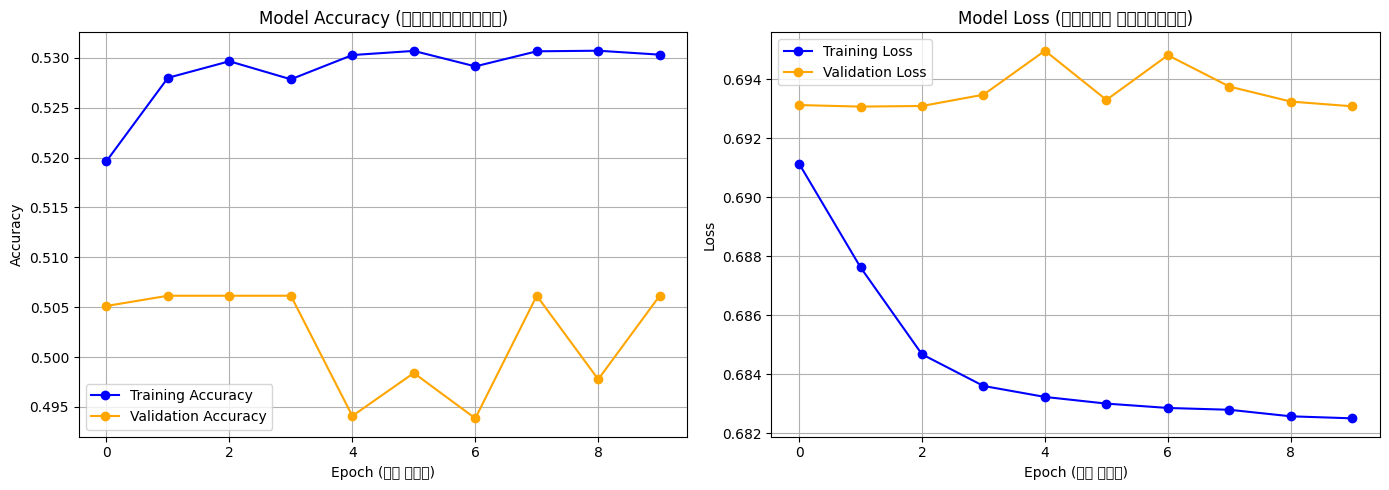

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', marker='o')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', marker='o')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()